In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer
from itertools import islice

# Stream OpenWebText without downloading the full dataset
dataset = load_dataset(
    "Skylion007/openwebtext",
    split="train",
    streaming=True
)

# Take 1,000 documents for EDA
sample_size = 1000
sample = list(islice(dataset, sample_size))

# Convert the sample into a DataFrame
df = pd.DataFrame(sample)

print("OpenWebText sample loaded successfully.")
print("Sample size:", len(df))

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

OpenWebText sample loaded successfully.
Sample size: 1000


In [8]:
# Inspect the structure of the sampled dataset

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset shape: (1000, 1)
Columns: ['text']

Data types:
text    str
dtype: object


In [9]:
# Preview the first OpenWebText document
print(df["text"].iloc[0][:300])

Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.

The decision left CNN Chief Medical Corresponden


In [10]:
# Check data quality of the OpenWebText sample

empty_documents = (df["text"].str.strip() == "").sum()
duplicate_documents = df["text"].duplicated().sum()

print("Empty documents:", empty_documents)
print("Duplicate documents:", duplicate_documents)

Empty documents: 0
Duplicate documents: 0


In [11]:
# Calculate the number of words in each document
df["word_count"] = df["text"].str.split().str.len()

# Key document length statistics
print("Mean word count:", round(df["word_count"].mean(), 2))
print("Median word count:", df["word_count"].median())
print("Minimum word count:", df["word_count"].min())
print("Maximum word count:", df["word_count"].max())

Mean word count: 822.17
Median word count: 538.5
Minimum word count: 128
Maximum word count: 14787


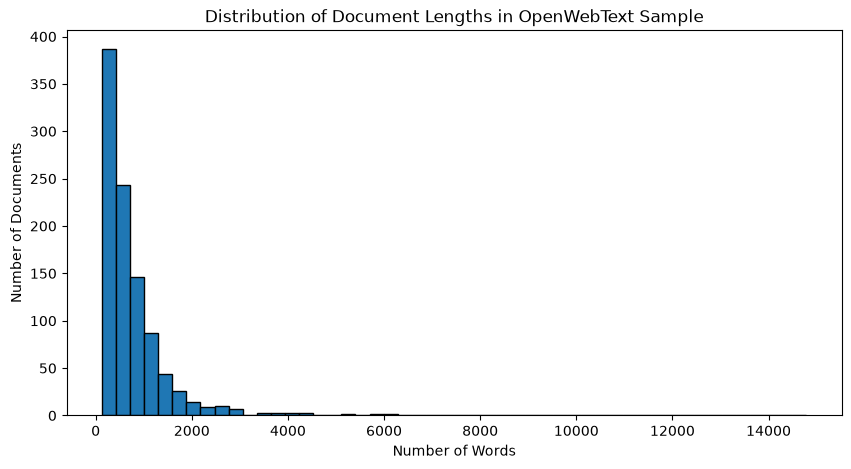

In [12]:
# Visualize the distribution of document lengths

plt.figure(figsize=(10, 5))

plt.hist(df["word_count"], bins=50, edgecolor="black")

plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.title("Distribution of Document Lengths in OpenWebText Sample")

plt.show()

In [13]:
# Load the GPT-2 tokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

print("GPT-2 tokenizer loaded successfully.")
print("Vocabulary size:", tokenizer.vocab_size)

GPT-2 tokenizer loaded successfully.
Vocabulary size: 50257


In [17]:
# Check the maximum sequence length supported by GPT-2
print("GPT-2 maximum context length:", tokenizer.model_max_length, "tokens")

GPT-2 maximum context length: 1024 tokens


In [14]:
# Take a short text segment from the first document
example_text = df["text"].iloc[0][:100]

# Convert the text into GPT-2 tokens
token_ids = tokenizer.encode(example_text, add_special_tokens=False)
tokens = tokenizer.convert_ids_to_tokens(token_ids)

print("Original text:")
print(example_text)

print("\nGPT-2 tokens:")
print(tokens)

print("\nNumber of tokens:", len(tokens))

Original text:
Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched do

GPT-2 tokens:
['Port', '-', 'au', '-', 'Prince', ',', 'ĠHaiti', 'Ġ(', 'CNN', ')', 'Ġ--', 'ĠEarthquake', 'Ġvictims', ',', 'Ġwr', 'ithing', 'Ġin', 'Ġpain', 'Ġand', 'Ġgrasping', 'Ġat', 'Ġlife', ',', 'Ġwatched', 'Ġdo']

Number of tokens: 25


In [15]:
# Calculate GPT-2 token count for each document
df["token_count"] = df["text"].apply(
    lambda text: len(tokenizer.encode(text, add_special_tokens=False))
)

print("Mean token count:", round(df["token_count"].mean(), 2))
print("Median token count:", df["token_count"].median())
print("Minimum token count:", df["token_count"].min())
print("Maximum token count:", df["token_count"].max())

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1217 > 1024). Running this sequence through the model will result in indexing errors


Mean token count: 1125.79
Median token count: 731.0
Minimum token count: 156
Maximum token count: 25939


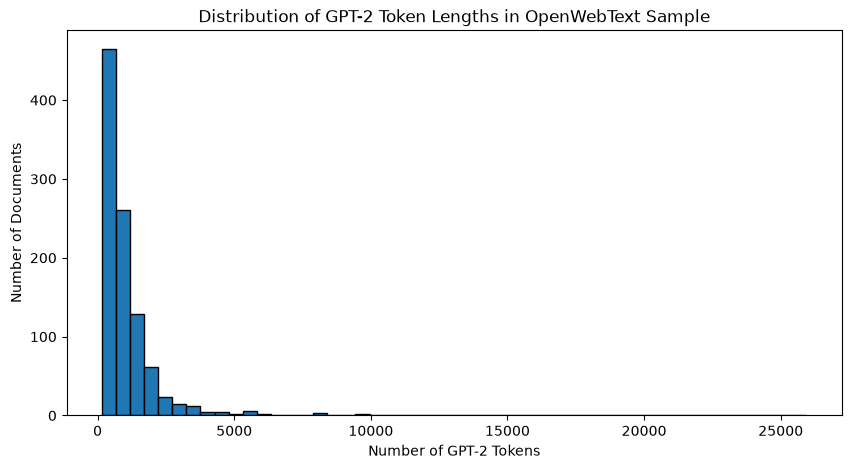

In [16]:
# Visualize GPT-2 token length distribution

plt.figure(figsize=(10, 5))

plt.hist(df["token_count"], bins=50, edgecolor="black")

plt.xlabel("Number of GPT-2 Tokens")
plt.ylabel("Number of Documents")
plt.title("Distribution of GPT-2 Token Lengths in OpenWebText Sample")

plt.show()

In [18]:
# GPT-2 Small maximum context length
gpt2_max_length = tokenizer.model_max_length

# Count documents within and beyond GPT-2's context limit
within_limit = (df["token_count"] <= gpt2_max_length).sum()
beyond_limit = (df["token_count"] > gpt2_max_length).sum()

print(f"Documents within 1024 tokens: {within_limit}")
print(f"Documents exceeding 1024 tokens: {beyond_limit}")

Documents within 1024 tokens: 661
Documents exceeding 1024 tokens: 339


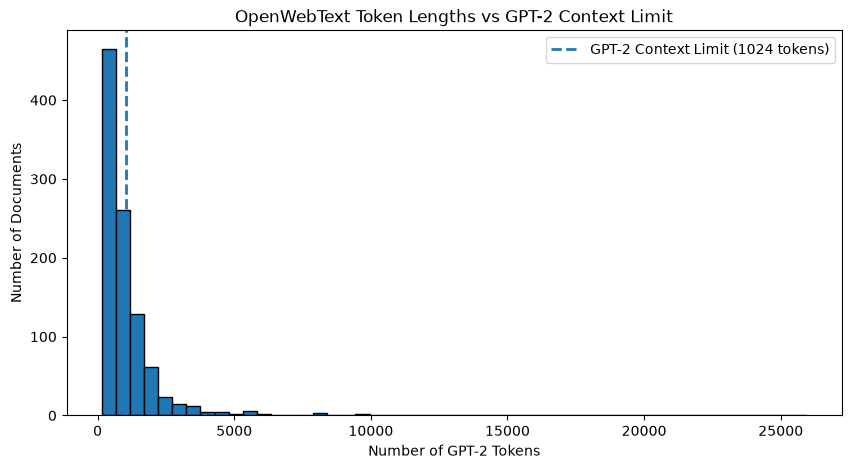

In [19]:
# Visualize document token lengths with GPT-2's context limit

plt.figure(figsize=(10, 5))

plt.hist(df["token_count"], bins=50, edgecolor="black")

# GPT-2 maximum context boundary
plt.axvline(
    x=1024,
    linestyle="--",
    linewidth=2,
    label="GPT-2 Context Limit (1024 tokens)"
)

plt.xlabel("Number of GPT-2 Tokens")
plt.ylabel("Number of Documents")
plt.title("OpenWebText Token Lengths vs GPT-2 Context Limit")
plt.legend()

plt.show()